Shape: (569, 30)
Distribusi taarget:
1    0.627
0    0.373
Name: proportion, dtype: float64
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


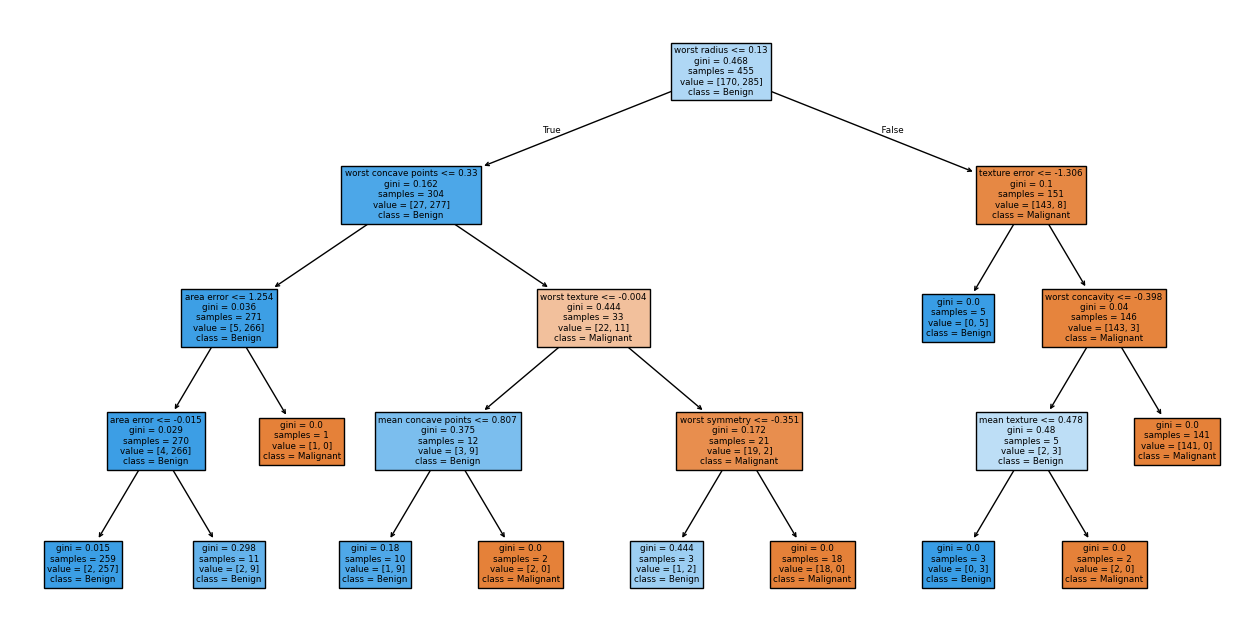


===Logistic Regression===
[[41  1]
 [ 1 71]]
Akurasi: 0.982
Presisi: 0.986
Recall: 0.986
F1 Score: 0.986

===Decision Tree===
[[42  0]
 [72  0]]
Akurasi: 0.368
Presisi: 0.000
Recall: 0.000
F1 Score: 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target
# 0=malignant, 1=benign
print('Shape:', x.shape)
print('Distribusi taarget:')
print(pd.Series(y).value_counts(normalize=True).round(3))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(x_train_s, y_train)
y_pred_log = log_model.predict(x_test_s)

coef_df = pd.DataFrame({'Fitur': x.columns,
'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

from sklearn. tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(x_train_s, y_train)
y_pred_tree = tree_model.predict (x_test)
plt.figure (figsize=(16, 8))
plot_tree (tree_model, feature_names=x.columns, class_names=['Malignant', 'Benign'], filled=True)
plt.show ()

from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n==={name}===")
    print (confusion_matrix(y_test, y_pred))
    print (f"Akurasi: {accuracy_score(y_test, y_pred):.3f}")
    print (f"Presisi: {precision_score(y_test, y_pred):.3f}")
    print (f"Recall: {recall_score(y_test, y_pred):.3f}")
    print (f"F1 Score: {f1_score(y_test, y_pred):.3f}")


1. Model logistic regression memiliki recall yang lebih tinggi dibandingkan  desicion tree.
2. Recall penting saat false negative (kanker terlewat) sehingga tidak melewatkan kasus positif yang sebenarnya.
3. Perbedaan performa yang ada adalah Logistic regression memberikan hasil yang lebih stabil dibandingkan dengan decision tree.